# Notebook 1: Data Preparation & Exploratory Data Analysis
**Project:** A/B Test Design for Household-Level Coupon Experiment
**Dataset:** dunnhumby - The Complete Journey

## 1. Setup & Data Loading

This notebook loads and explores the dunnhumby "Complete Journey" dataset, which contains 2 years of household-level grocery transactions for ~2,500 frequent shoppers. We join the data tables and lookup tables, engineer household-level features, and build pre-period baselines that will feed into our experiment design in Notebook 2.

**Tables used:**
| Table | Type | Description |
|---|---|---|
| `transaction_data` | Data | Line-item purchases (receipt-level) |
| `hh_demographic` | Data | Demographic segmentation for a subset of households |
| `campaign_table` | Data | Campaigns received by each household |
| `campaign_desc` | Lookup | Campaign type and date ranges |
| `coupon` | Lookup | Coupons tied to campaigns and products |
| `coupon_redempt` | Lookup | Coupons actually redeemed by households |
| `product` | Lookup | Product attributes (department, brand, etc.) |
| `causal_data` | Lookup | In-store display and mailer features per product-store-week |

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

os.chdir(r"C:\Users\David Cho\OneDrive\Desktop\Projects\AB Testing\Experiment Design\The Complete Journey")
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_DIR = './data/'

# ── Load all tables ──────────────────────────────────────────────────────────
transactions = pd.read_csv(DATA_DIR + 'transaction_data.csv')
demographics = pd.read_csv(DATA_DIR + 'hh_demographic.csv')
campaign_table = pd.read_csv(DATA_DIR + 'campaign_table.csv')
campaign_desc = pd.read_csv(DATA_DIR + 'campaign_desc.csv')
coupon = pd.read_csv(DATA_DIR + 'coupon.csv')
coupon_redempt = pd.read_csv(DATA_DIR + 'coupon_redempt.csv')
product = pd.read_csv(DATA_DIR + 'product.csv')
causal_data = pd.read_csv(DATA_DIR + 'causal_data.csv')

print("Tables loaded successfully.")
print(f"  transactions:   {transactions.shape}")
print(f"  demographics:   {demographics.shape}")
print(f"  campaign_table: {campaign_table.shape}")
print(f"  campaign_desc:  {campaign_desc.shape}")
print(f"  coupon:         {coupon.shape}")
print(f"  coupon_redempt: {coupon_redempt.shape}")
print(f"  product:        {product.shape}")
print(f"  causal_data:    {causal_data.shape}")

Tables loaded successfully.
  transactions:   (2595732, 12)
  demographics:   (801, 8)
  campaign_table: (7208, 3)
  campaign_desc:  (30, 4)
  coupon:         (124548, 3)
  coupon_redempt: (2318, 4)
  product:        (92353, 7)
  causal_data:    (36786524, 5)


## 2. Initial Data Exploration

Before joining tables we inspect each one for data types, missing values, and key distributions.

In [2]:
# Transaction Table
print("=== transaction_data ===")
print(f"\nColumn dtypes:\n{transactions.dtypes}")
print(f"\nMissing values:\n{transactions.isnull().sum()}")
print(f"\nQuantity, Sales Value:")
print(transactions[['QUANTITY', 'SALES_VALUE']].describe())
print()
transactions.head(2)

=== transaction_data ===

Column dtypes:
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

Missing values:
household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
TRANS_TIME           0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64

Quantity, Sales Value:
        QUANTITY  SALES_VALUE
count 2595732.00   2595732.00
mean      100.43         3.10
std      1153.44         4.18
min         0.00         0.00
25%         1.00         1.29
50%         1.00         2.00
75%         1.00         3.49
max     89638.00       840.

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.00,0.00
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.00,0.00


In [5]:
print('Retail Discount:\n', transactions.loc[transactions['RETAIL_DISC'] < 0, 'RETAIL_DISC'].describe())
print()
print('Coupon Discount:\n', transactions.loc[transactions['COUPON_DISC'] < 0, 'COUPON_DISC'].describe())
print()
print('Coupon Retailer Match Discount:\n', transactions.loc[transactions['COUPON_MATCH_DISC'] < 0, 'COUPON_MATCH_DISC'].describe())
print()
print('Positive Discount')
print('  Retail Discount:                ', sum(transactions['RETAIL_DISC']>0))
print('  Coupon Discount:                ', sum(transactions['COUPON_DISC']>0))
print('  Coupon Retailer Match Discount: ', sum(transactions['COUPON_MATCH_DISC']>0))

Retail Discount:
 count   1303026.00
mean         -1.07
std           1.59
min        -180.00
25%          -1.22
50%          -0.69
75%          -0.32
max          -0.00
Name: RETAIL_DISC, dtype: float64

Coupon Discount:
 count   36422.00
mean       -1.17
std         1.41
min       -55.93
25%        -1.00
50%        -1.00
75%        -0.50
max        -0.08
Name: COUPON_DISC, dtype: float64

Coupon Retailer Match Discount:
 count   17449.00
mean       -0.43
std         0.22
min        -7.70
25%        -0.50
50%        -0.45
75%        -0.30
max        -0.01
Name: COUPON_MATCH_DISC, dtype: float64

Positive Discount
  Retail Discount:                 36
  Coupon Discount:                 0
  Coupon Retailer Match Discount:  0


In [9]:
# Key counts
print(f"Unique households:  {transactions['household_key'].nunique()}")
print(f"Unique baskets:     {transactions['BASKET_ID'].nunique()}")
print(f"Unique products:    {transactions['PRODUCT_ID'].nunique()}")
print(f"Unique stores:      {transactions['STORE_ID'].nunique()}")
print(f"Day range:          {transactions['DAY'].min()} – {transactions['DAY'].max()}")
print(f"Week range:         {transactions['WEEK_NO'].min()} – {transactions['WEEK_NO'].max()}")

Unique households:  2500
Unique baskets:     276484
Unique products:    92339
Unique stores:      582
Day range:          1 – 711
Week range:         1 – 102


In [11]:
# Household demographics Table
print("=== hh_demographic ===")
print(f"Unique households with demographics: {demographics['household_key'].nunique()}")
print(f"\nColumn dtypes:\n{transactions.dtypes}")
print(f"\nMissing values:\n{demographics.isnull().sum()}")
print(f"\nValue counts for each classification:")
for col in demographics.columns:
    if col != 'household_key':
        print()
        print(demographics[col].value_counts(dropna=False))

print()
demographics.head(2)

=== hh_demographic ===
Unique households with demographics: 801

Column dtypes:
household_key          int64
BASKET_ID              int64
DAY                    int64
PRODUCT_ID             int64
QUANTITY               int64
SALES_VALUE          float64
STORE_ID               int64
RETAIL_DISC          float64
TRANS_TIME             int64
WEEK_NO                int64
COUPON_DISC          float64
COUPON_MATCH_DISC    float64
dtype: object

Missing values:
classification_1     0
classification_2     0
classification_3     0
HOMEOWNER_DESC       0
classification_5     0
classification_4     0
KID_CATEGORY_DESC    0
household_key        0
dtype: int64

Value counts for each classification:

classification_1
Age Group4    288
Age Group3    194
Age Group2    142
Age Group6     72
Age Group5     59
Age Group1     46
Name: count, dtype: int64

classification_2
Y    344
X    340
Z    117
Name: count, dtype: int64

classification_3
Level5     192
Level4     172
Level6      96
Level3      77
Leve

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
0,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown,1
1,Age Group4,X,Level5,Homeowner,Group5,2,None/Unknown,7


In [13]:
# Campaign table
print("=== campaign_table ===")
print(f"\nUnique households targeted: {campaign_table['household_key'].nunique()}")
print(f"Unique campaigns:          {campaign_table['CAMPAIGN'].nunique()}")
print(f"\nCampaign type distribution:\n{campaign_table['DESCRIPTION'].value_counts()}")

print("\n=== campaign_desc ===")
print(campaign_desc.sort_values('CAMPAIGN'))
print(f"\nCampaign types: {campaign_desc['DESCRIPTION'].value_counts().to_dict()}")
print()
campaign_table.head(2)

=== campaign_table ===

Unique households targeted: 1584
Unique campaigns:          30

Campaign type distribution:
DESCRIPTION
TypeA    3979
TypeB    2655
TypeC     574
Name: count, dtype: int64

=== campaign_desc ===
   DESCRIPTION  CAMPAIGN  START_DAY  END_DAY
23       TypeB         1        346      383
24       TypeB         2        351      383
20       TypeC         3        356      412
22       TypeB         4        372      404
21       TypeB         5        377      411
19       TypeC         6        393      425
18       TypeB         7        398      432
17       TypeA         8        412      460
16       TypeB         9        435      467
15       TypeB        10        463      495
13       TypeB        11        477      523
14       TypeB        12        477      509
12       TypeA        13        504      551
10       TypeC        14        531      596
1        TypeC        15        547      708
11       TypeB        16        561      593
9        TypeB  

,DESCRIPTION,household_key,CAMPAIGN
0,TypeA,17,26
1,TypeA,27,26


In [15]:
# Coupon Table
print("=== coupon ===")
print(f"Unique coupons: {coupon['COUPON_UPC'].nunique()}")
print(f"Unique products covered: {coupon['PRODUCT_ID'].nunique()}")
print(coupon.head())

print("\n=== coupon_redempt ===")
print(f"Unique households that redeemed: {coupon_redempt['household_key'].nunique()}")
print(f"Total redemptions: {len(coupon_redempt)}")
print(coupon_redempt.head())

=== coupon ===
Unique coupons: 1135
Unique products covered: 44133
    COUPON_UPC  PRODUCT_ID  CAMPAIGN
0  10000089061       27160         4
1  10000089064       27754         9
2  10000089073       28897        12
3  51800009050       28919        28
4  52100000076       28929        25

=== coupon_redempt ===
Unique households that redeemed: 434
Total redemptions: 2318
   household_key  DAY   COUPON_UPC  CAMPAIGN
0              1  421  10000085364         8
1              1  421  51700010076         8
2              1  427  54200000033         8
3              1  597  10000085476        18
4              1  597  54200029176        18


In [17]:
# Product Table
print("=== product ===")
print(f"Shape: {product.shape}")
print(f"Unique departments: {product['DEPARTMENT'].nunique()}")
print(f"Brand split:\n{product['BRAND'].value_counts()}")
print(f"\nTop 10 departments:\n{product['DEPARTMENT'].value_counts().head(10)}")
product.head()

=== product ===
Shape: (92353, 7)
Unique departments: 44
Brand split:
BRAND
National    78537
Private     13816
Name: count, dtype: int64

Top 10 departments:
DEPARTMENT
GROCERY       39021
DRUG GM       31529
PRODUCE        3118
COSMETICS      3011
NUTRITION      2914
MEAT           2544
MEAT-PCKGD     2427
DELI           2354
PASTRY         2149
FLORAL          938
Name: count, dtype: int64


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


## 3. Data Joining & Feature Engineering

### Join Strategy

We build a **household-level analytical table** by:
1. Enriching `transaction_data` with `product` info (department, brand)
2. Aggregating transactions to household level with behavioral features
3. Left-joining `hh_demographic` for demographic attributes
4. Left-joining campaign/coupon redemption summaries

### Time Periods

The dataset spans **weeks 1–102** (~2 years). We define:
- **Pre-period (baseline):** Weeks 1–71 (first ~68% of data, ~17 months)
- **Post-period (experiment window):** Weeks 72–102 (last ~30 weeks, ~7 months)

This split gives enough pre-period history for stable baselines while leaving a realistic experiment window.

### 3a. Enriching Transaction Data with Product Info

In [140]:
txn = transactions[transactions['RETAIL_DISC'] <= 0].merge(product[['PRODUCT_ID', 'DEPARTMENT', 'BRAND']], 
                          on='PRODUCT_ID', how='left')

# Calculate actual prices per the data description
# Loyalty card price = (sales_value - (retail_disc + coupon_match_disc)) / quantity
# Non-loyalty card price = (sales_value - coupon_match_disc) / quantity
txn['loyalty_price'] = (txn['SALES_VALUE'] - (txn['RETAIL_DISC'] + txn['COUPON_MATCH_DISC'])) / txn['QUANTITY']
txn['non_loyalty_price'] = (txn['SALES_VALUE'] - txn['COUPON_MATCH_DISC']) / txn['QUANTITY']
txn['total_discount'] = txn['RETAIL_DISC'].abs() + txn['COUPON_DISC'].abs() + txn['COUPON_MATCH_DISC'].abs()
txn['used_coupon'] = (txn['COUPON_DISC'] != 0).astype(int)
txn['discounted_coupon'] = (txn['COUPON_MATCH_DISC'] != 0).astype(int)
txn['used_loyalty'] = (txn['RETAIL_DISC'] != 0).astype(int)

print(f"Enriched transaction shape: {txn.shape}")
txn.head()

Enriched transaction shape: (2595696, 20)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC,DEPARTMENT,BRAND,loyalty_price,non_loyalty_price,total_discount,used_coupon,discounted_coupon,used_loyalty
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.00,0.00,PRODUCE,Private,1.99,1.39,0.60,0,0,1
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.00,0.00,PRODUCE,National,0.82,0.82,0.00,0,0,0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.00,0.00,PRODUCE,Private,1.29,0.99,0.30,0,0,1
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.00,0.00,PRODUCE,National,1.21,1.21,0.00,0,0,0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.00,0.00,PRODUCE,Private,1.89,1.50,0.39,0,0,1


### 3b. Define pre/post periods

In [142]:
PRE_PERIOD_END = 71     # Weeks 1-71 = pre-period (~17 months)
POST_PERIOD_START = 72  # Weeks 72-102 = post-period (~7 months)

txn_pre = txn[txn['WEEK_NO'] <= PRE_PERIOD_END].copy()
txn_post = txn[txn['WEEK_NO'] >= POST_PERIOD_START].copy()

print(f"Pre-period transactions:  {len(txn_pre):,}  (weeks 1–{PRE_PERIOD_END})")
print(f"Post-period transactions: {len(txn_post):,}  (weeks {POST_PERIOD_START}–102)")

Pre-period transactions:  1,717,581  (weeks 1–71)
Post-period transactions: 878,115  (weeks 72–102)


### 3c. Build Household-Level Feature Table (Pre-Period)

For each household, we compute baseline features from the **pre-period** only:

| Feature Group | Variables |
|---|---|
| **Spend** | Total spend, avg weekly spend, avg basket size |
| **Frequency** | Total trips, avg trips per week, total items |
| **Recency** | Last purchase day, weeks since last purchase |
| **Promotion responsiveness** | Coupon usage rate, loyalty discount rate, avg discount per trip |
| **Category affinity** | Top department, number of distinct departments |
| **Demographics** | Age group, income, household size, kids, homeowner |

In [144]:
# Spend & frequency features
hh_spend = txn_pre.groupby('household_key').agg(
    total_spend         = ('SALES_VALUE', 'sum'),
    total_items         = ('QUANTITY', 'sum'),
    total_trips         = ('BASKET_ID', 'nunique'),
    total_days_active   = ('DAY', 'nunique'),
    total_weeks_active  = ('WEEK_NO', 'nunique'),
    n_products          = ('PRODUCT_ID', 'nunique'),
    n_stores            = ('STORE_ID', 'nunique'),
    n_departments       = ('DEPARTMENT', 'nunique'),
    last_purchase_day   = ('DAY', 'max'),
    first_purchase_day  = ('DAY', 'min'),
    first_purchase_week = ('WEEK_NO', 'min'),
    avg_basket_value    = ('SALES_VALUE', 'mean'),
).reset_index()

# Weeks active
pre_weeks = PRE_PERIOD_END  # total weeks in pre-period
hh_spend['avg_weekly_spend'] = hh_spend['total_spend'] / (PRE_PERIOD_END - hh_spend['first_purchase_week'] +  1)
hh_spend['avg_trips_per_week'] = hh_spend['total_trips'] / (PRE_PERIOD_END - hh_spend['first_purchase_week'] +  1)
hh_spend['items_per_trip'] = hh_spend['total_items'] / hh_spend['total_trips']
hh_spend['spend_per_trip'] = hh_spend['total_spend'] / hh_spend['total_trips']

# Recency: days since last purchase relative to end of pre-period
max_pre_day = txn_pre['DAY'].max()
hh_spend['recency_days'] = max_pre_day - hh_spend['last_purchase_day']

# Promotion responsiveness
hh_promo = txn_pre.groupby('household_key').agg(
    coupon_usage_rate  = ('used_coupon', 'mean'),
    discounted_coupon_rate = ('discounted_coupon', 'mean'),
    loyalty_usage_rate = ('used_loyalty', 'mean'),
    total_discount     = ('total_discount', 'sum'),
    n_coupon_items     = ('used_coupon', 'sum'),
    n_coupon_discount_items = ('discounted_coupon', 'sum')
).reset_index()
hh_promo['discount_per_trip'] = hh_promo['total_discount'] / hh_spend.set_index('household_key').loc[hh_promo['household_key'], 'total_trips'].values

# Top department per household
top_dept = (txn_pre.groupby(['household_key', 'DEPARTMENT'])['SALES_VALUE']
            .sum().reset_index()
            .sort_values('SALES_VALUE', ascending=False)
            .drop_duplicates('household_key'))
top_dept = top_dept[['household_key', 'DEPARTMENT']].rename(columns={'DEPARTMENT': 'top_department'})

# Merge all household features
hh_features = (hh_spend
               .merge(hh_promo, on='household_key', how='left')
               .merge(top_dept, on='household_key', how='left'))

print(f"Household feature table shape: {hh_features.shape}")
hh_features.head()

Household feature table shape: (2498, 26)


,household_key,total_spend,total_items,total_trips,total_days_active,total_weeks_active,n_products,n_stores,n_departments,last_purchase_day,first_purchase_day,first_purchase_week,avg_basket_value,avg_weekly_spend,avg_trips_per_week,items_per_trip,spend_per_trip,recency_days,coupon_usage_rate,discounted_coupon_rate,loyalty_usage_rate,total_discount,n_coupon_items,n_coupon_discount_items,discount_per_trip,top_department
0,1,2931.28,1370,54,48,45,497,2,13,494,51,8,2.52,45.80,0.84,25.37,54.28,1,0.07,0.05,0.45,594.68,83,55,11.01,GROCERY
1,2,1385.24,579,36,36,27,403,5,11,489,103,15,2.82,24.30,0.63,16.08,38.48,6,0.01,0.00,0.43,260.97,3,0,7.25,GROCERY
2,3,2396.90,1439,40,39,30,465,2,10,477,113,17,2.96,43.58,0.73,35.98,59.92,18,0.07,0.04,0.57,711.45,53,35,17.79,GROCERY
3,4,1034.68,321,25,25,21,144,5,9,467,104,16,3.95,18.48,0.45,12.84,41.39,28,0.00,0.00,0.43,104.68,1,0,4.19,GROCERY
4,5,638.14,216,31,25,20,174,2,8,480,85,13,3.26,10.82,0.53,6.97,20.59,15,0.00,0.00,0.54,106.96,0,0,3.45,GROCERY


### 3d. Join Demographics

In [146]:
# Rename demographic columns for clarity based on observed values
demo_renamed = demographics.rename(columns={
    'classification_1': 'age_group',
    'classification_2': 'marital_status',      # X, Y, Z
    'classification_3': 'income_level',         # Level1-Level12 (ordinal)
    'HOMEOWNER_DESC':   'homeowner',
    'classification_4': 'household_size',       # 1, 2, 3 (ordinal)
    'classification_5': 'household_comp',       # Group1-Group5 (ordinal)
    'KID_CATEGORY_DESC':'kid_category',
})

hh_features = hh_features.merge(demo_renamed, on='household_key', how='left')
print(f"After demographics join: {hh_features.shape}")
print(f"Households WITH demographics: {hh_features['age_group'].notna().sum()}")
print(f"Households WITHOUT demographics: {hh_features['age_group'].isna().sum()}")

After demographics join: (2498, 33)
Households WITH demographics: 801
Households WITHOUT demographics: 1697


### 3e. Join campaign & coupon redemption history

In [148]:
campaign_desc['Pre'] = np.where(campaign_desc['END_DAY'] <= max_pre_day, 1 , 0)
campaign_table_pre = campaign_table.merge(campaign_desc[['DESCRIPTION', 'CAMPAIGN', 'Pre']], on=['DESCRIPTION', 'CAMPAIGN'], how='left')
campaign_table_pre = campaign_table_pre[campaign_table_pre['Pre']==1].copy()

# Number of campaigns received per household
campaign_counts = campaign_table_pre.groupby('household_key').agg(
    n_campaigns_received = ('CAMPAIGN', 'nunique'),
).reset_index()

# Campaign types received
campaign_type_counts = (campaign_table_pre.groupby(['household_key', 'DESCRIPTION'])
                        .size().unstack(fill_value=0)
                        .rename(columns=lambda x: f'n_campaigns_{x}')
                        .reset_index())

# Coupon redemption summary
coupon_redempt['Pre'] = np.where(coupon_redempt['DAY'] <= max_pre_day, 1, 0) 
coupon_redempt_pre = coupon_redempt[coupon_redempt['Pre']==1].copy()

redempt_counts = coupon_redempt_pre.groupby('household_key').agg(
    n_coupons_redeemed = ('COUPON_UPC', 'count'),
    n_campaigns_redeemed = ('CAMPAIGN', 'nunique'),
).reset_index()

# Merge
hh_features = (hh_features
               .merge(campaign_counts, on='household_key', how='left')
               .merge(campaign_type_counts, on='household_key', how='left')
               .merge(redempt_counts, on='household_key', how='left'))

# Fill NaN for households with no campaign/redemption history
fill_cols = ['n_campaigns_received', 'n_coupons_redeemed', 'n_campaigns_redeemed']
for col in fill_cols:
    if col in hh_features.columns:
        hh_features[col] = hh_features[col].fillna(0).astype(int)

# Fill campaign type columns
for col in hh_features.columns:
    if col.startswith('n_campaigns_Type'):
        hh_features[col] = hh_features[col].fillna(0).astype(int)

# Redemption rate
hh_features['has_redeemed'] = (hh_features['n_coupons_redeemed'] > 0).astype(int)

print(f"Final household feature table: {hh_features.shape}")
hh_features.head()

Final household feature table: (2498, 40)


,household_key,total_spend,total_items,total_trips,total_days_active,total_weeks_active,n_products,n_stores,n_departments,last_purchase_day,first_purchase_day,first_purchase_week,avg_basket_value,avg_weekly_spend,avg_trips_per_week,...,top_department,age_group,marital_status,income_level,homeowner,household_comp,household_size,kid_category,n_campaigns_received,n_campaigns_TypeA,n_campaigns_TypeB,n_campaigns_TypeC,n_coupons_redeemed,n_campaigns_redeemed,has_redeemed
0,1,2931.28,1370,54,48,45,497,2,13,494,51,8,2.52,45.80,0.84,...,GROCERY,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown,2,1,1,0,3,1,1
1,2,1385.24,579,36,36,27,403,5,11,489,103,15,2.82,24.30,0.63,...,GROCERY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0
2,3,2396.90,1439,40,39,30,465,2,10,477,113,17,2.96,43.58,0.73,...,GROCERY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,0
3,4,1034.68,321,25,25,21,144,5,9,467,104,16,3.95,18.48,0.45,...,GROCERY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,0
4,5,638.14,216,31,25,20,174,2,8,480,85,13,3.26,10.82,0.53,...,GROCERY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0


## 4. Exploratory Data Analysis

### 4a. Spend Distribution

Understanding the shape of household spending is critical for power analysis — highly skewed distributions inflate variance and require larger sample sizes or variance-reduction techniques.

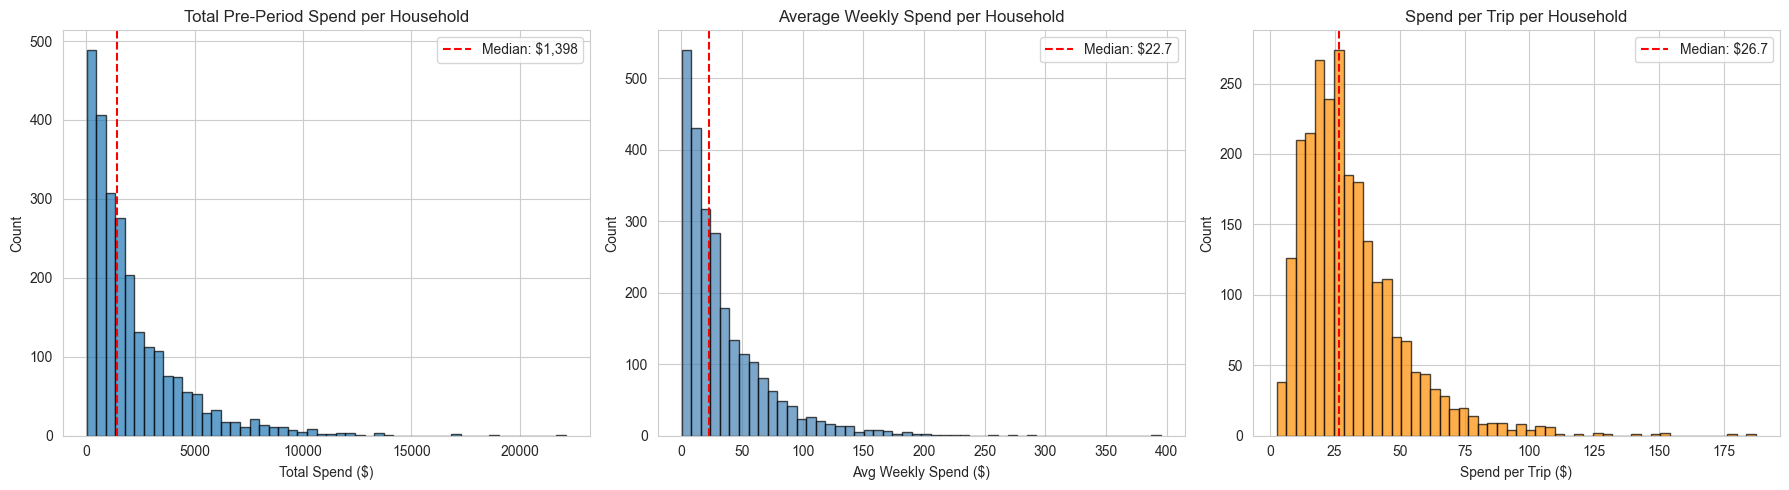

=== Key Spend Statistics (Pre-Period, per household) ===
       total_spend  avg_weekly_spend  spend_per_trip  total_trips  \
count      2498.00           2498.00         2498.00      2498.00   
mean       2116.28             34.22           31.25        74.28   
std        2247.84             36.42           19.76        81.45   
min           3.55              0.06            2.57         1.00   
25%         576.49              9.27           18.04        24.00   
50%        1398.20             22.72           26.71        51.00   
75%        2874.18             46.90           39.56        95.00   
max       22133.48            395.24          187.28       979.00   

       items_per_trip  
count         2498.00  
mean           683.88  
std           1252.62  
min              1.00  
25%             11.78  
50%             43.03  
75%            902.08  
max          17376.05  


In [150]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total spend
axes[0].hist(hh_features['total_spend'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Total Pre-Period Spend per Household')
axes[0].set_xlabel('Total Spend ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(hh_features['total_spend'].median(), color='red', linestyle='--', label=f"Median: ${hh_features['total_spend'].median():,.0f}")
axes[0].legend()

# Average weekly spend
axes[1].hist(hh_features['avg_weekly_spend'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_title('Average Weekly Spend per Household')
axes[1].set_xlabel('Avg Weekly Spend ($)')
axes[1].set_ylabel('Count')
axes[1].axvline(hh_features['avg_weekly_spend'].median(), color='red', linestyle='--', label=f"Median: ${hh_features['avg_weekly_spend'].median():,.1f}")
axes[1].legend()

# Spend per trip
axes[2].hist(hh_features['spend_per_trip'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[2].set_title('Spend per Trip per Household')
axes[2].set_xlabel('Spend per Trip ($)')
axes[2].set_ylabel('Count')
axes[2].axvline(hh_features['spend_per_trip'].median(), color='red', linestyle='--', label=f"Median: ${hh_features['spend_per_trip'].median():,.1f}")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("=== Key Spend Statistics (Pre-Period, per household) ===")
spend_stats = hh_features[['total_spend', 'avg_weekly_spend', 'spend_per_trip', 'total_trips', 'items_per_trip']].describe()
print(spend_stats.round(2))

### 4b. Trip Frequency & Recency

Trip frequency and recency help us understand engagement levels and define eligibility criteria for the experiment (e.g., excluding churned households).

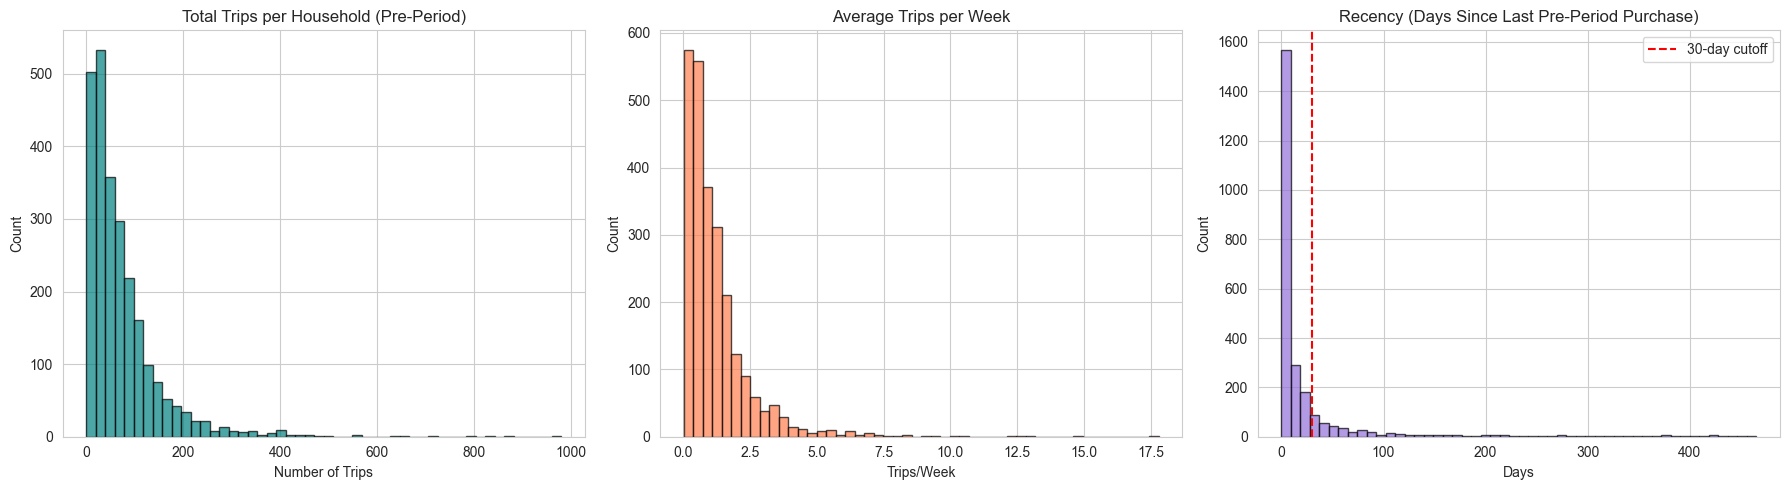

Recency percentiles:
count   2498.00
mean      27.10
std       66.00
min        0.00
25%        1.00
50%        5.00
75%       19.80
90%       63.00
95%      139.20
max      465.00
Name: recency_days, dtype: float64


In [152]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(hh_features['total_trips'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title('Total Trips per Household (Pre-Period)')
axes[0].set_xlabel('Number of Trips')
axes[0].set_ylabel('Count')

axes[1].hist(hh_features['avg_trips_per_week'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Average Trips per Week')
axes[1].set_xlabel('Trips/Week')
axes[1].set_ylabel('Count')

axes[2].hist(hh_features['recency_days'], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[2].set_title('Recency (Days Since Last Pre-Period Purchase)')
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Count')
axes[2].axvline(30, color='red', linestyle='--', label='30-day cutoff')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Recency percentiles:")
print(hh_features['recency_days'].describe(percentiles=[.25, .5, .75, .9, .95]).round(1))

### 4c. Promotion Responsiveness

Coupon and loyalty card usage patterns help us understand which households are price-sensitive and likely to respond to our proposed coupon intervention.

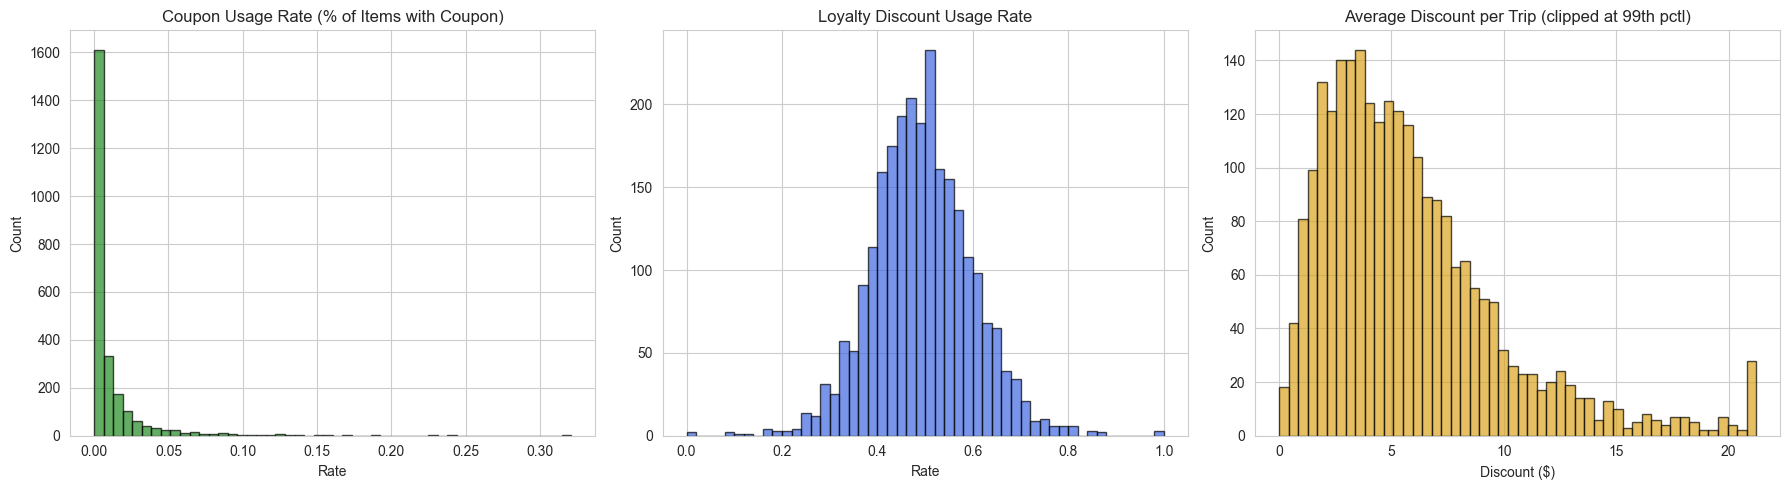

Campaign & redemption summary:
  Households who received campaigns: 1307
  Households who redeemed coupons:   228
  Redemption rate (among campaign recipients): 17.4%


In [154]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(hh_features['coupon_usage_rate'], bins=50, edgecolor='black', alpha=0.7, color='forestgreen')
axes[0].set_title('Coupon Usage Rate (% of Items with Coupon)')
axes[0].set_xlabel('Rate')
axes[0].set_ylabel('Count')

axes[1].hist(hh_features['loyalty_usage_rate'], bins=50, edgecolor='black', alpha=0.7, color='royalblue')
axes[1].set_title('Loyalty Discount Usage Rate')
axes[1].set_xlabel('Rate')
axes[1].set_ylabel('Count')

axes[2].hist(hh_features['discount_per_trip'].clip(upper=hh_features['discount_per_trip'].quantile(0.99)), 
             bins=50, edgecolor='black', alpha=0.7, color='goldenrod')
axes[2].set_title('Average Discount per Trip (clipped at 99th pctl)')
axes[2].set_xlabel('Discount ($)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Campaign & redemption summary:")
print(f"  Households who received campaigns: {(hh_features['n_campaigns_received'] > 0).sum()}")
print(f"  Households who redeemed coupons:   {(hh_features['has_redeemed'] > 0).sum()}")
print(f"  Redemption rate (among campaign recipients): {hh_features.loc[hh_features['n_campaigns_received'] > 0, 'has_redeemed'].mean():.1%}")

### 4d. Demographic Breakdown

Only a subset of households have demographics. We explore the distribution of these attributes among households that do have them.

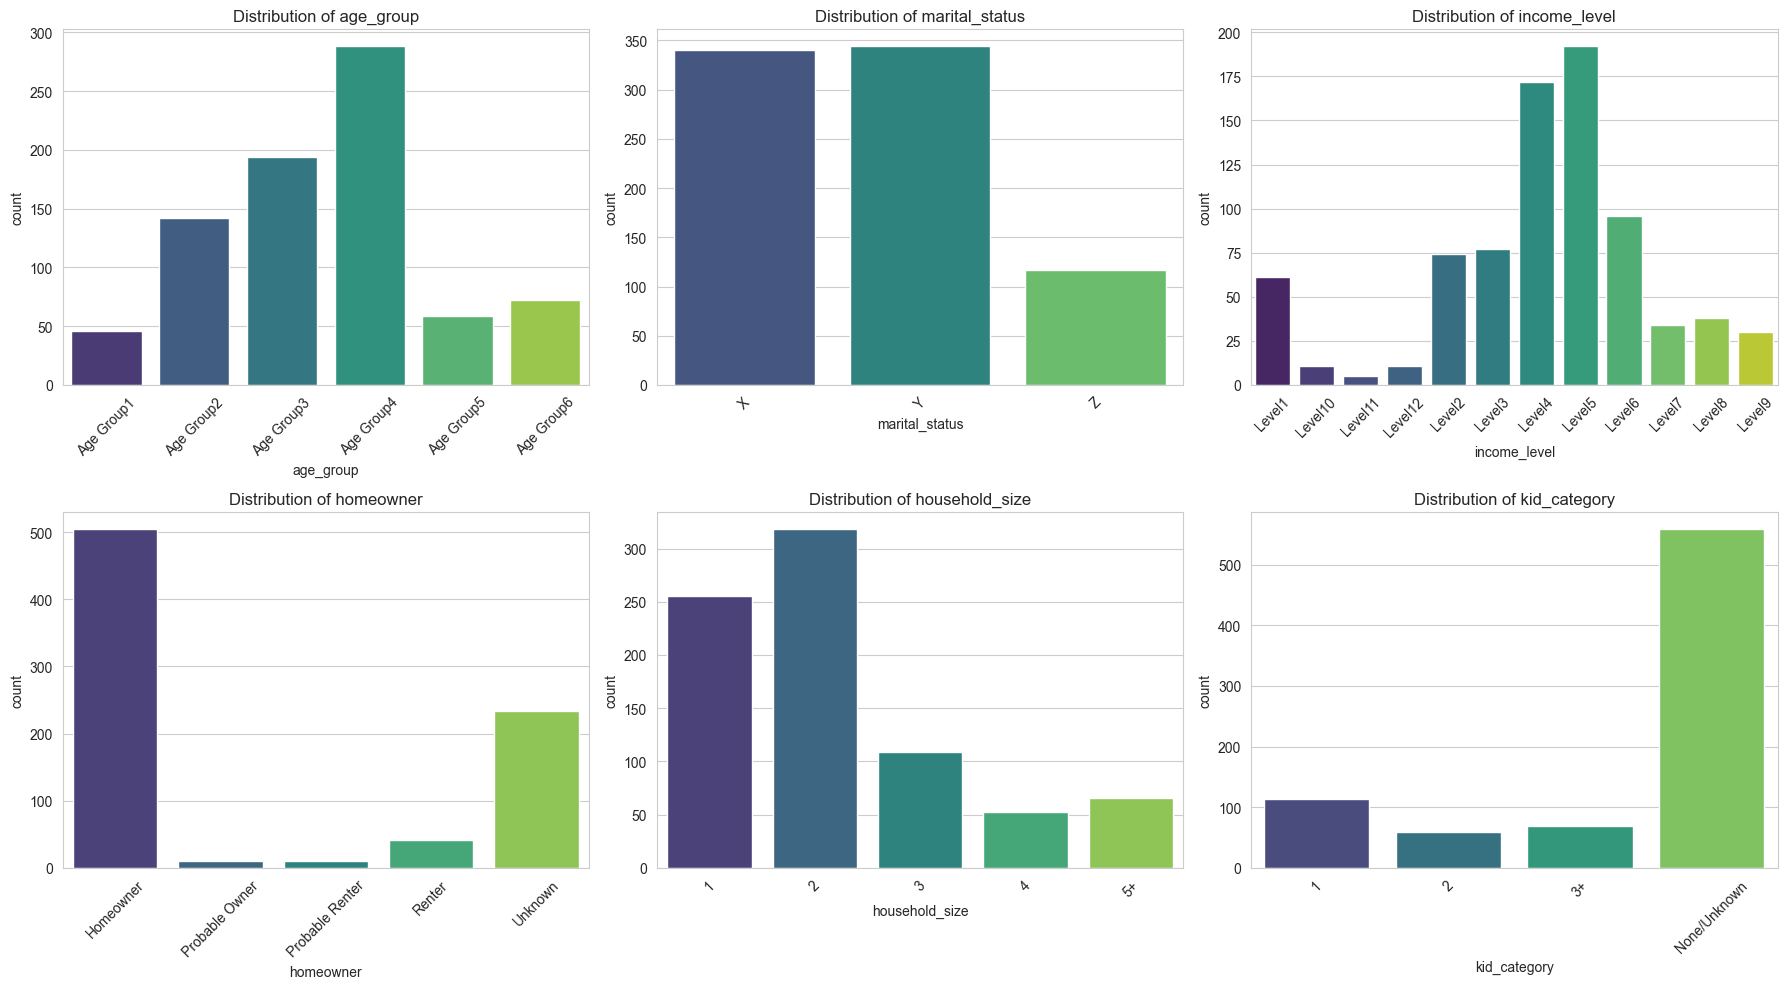

In [156]:
demo_cols = ['age_group', 'marital_status', 'income_level', 'homeowner', 'household_size', 'kid_category']
hh_with_demo = hh_features.dropna(subset=['age_group'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(demo_cols):
    ax = axes[i // 3, i % 3]
    order = sorted(hh_with_demo[col].unique())
    sns.countplot(data=hh_with_demo, x=col, order=order, ax=ax, palette='viridis')
    ax.set_title(f'Distribution of {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 4e. Weekly Spend Trends

We examine how aggregate spending evolves over the 102-week period to identify seasonality, trends, and a natural break point for pre/post periods.

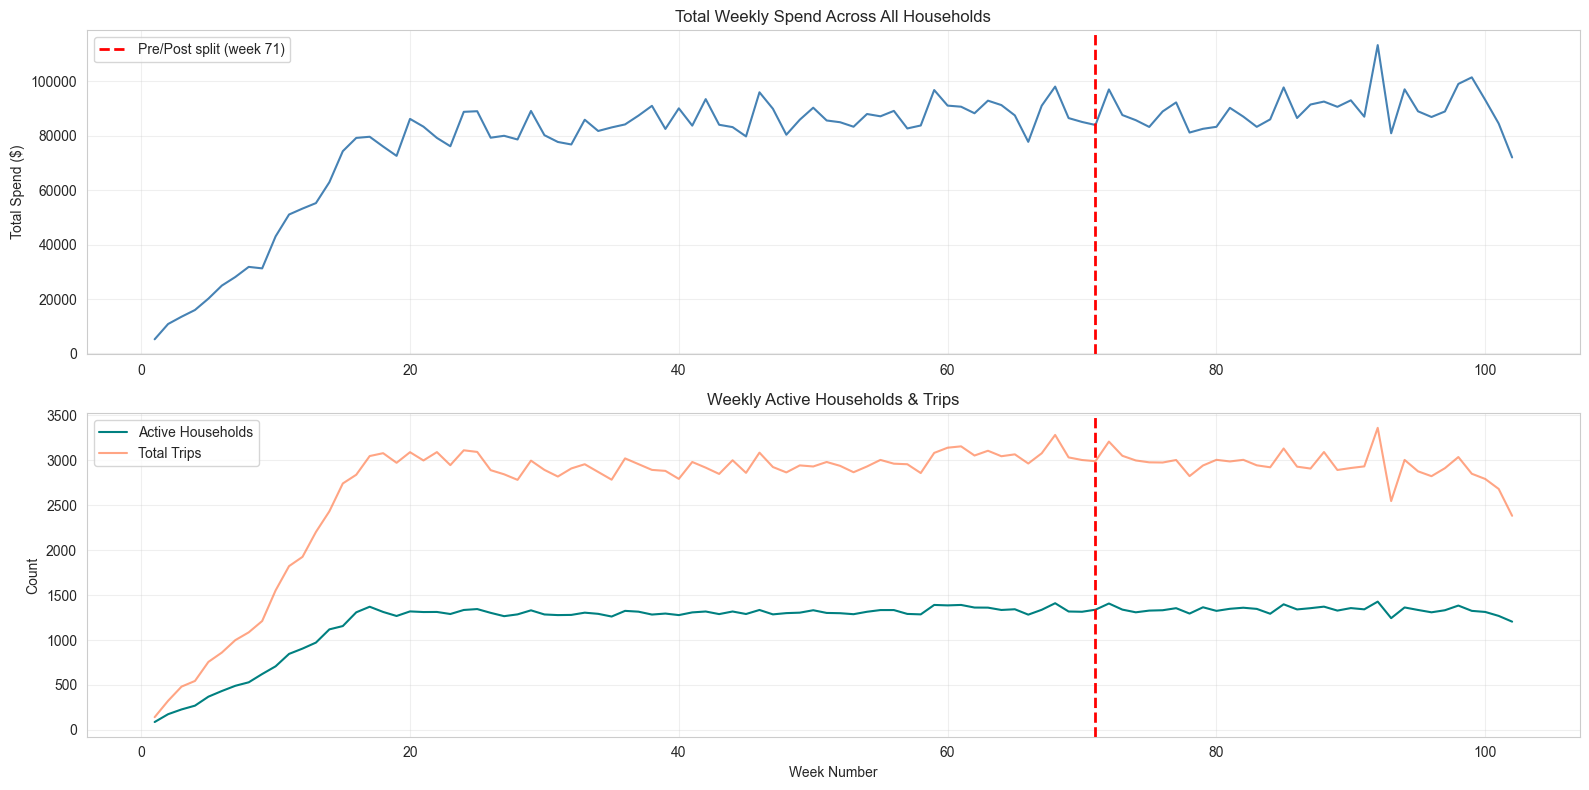

In [158]:
weekly = txn.groupby('WEEK_NO').agg(
    total_spend = ('SALES_VALUE', 'sum'),
    n_households = ('household_key', 'nunique'),
    n_trips = ('BASKET_ID', 'nunique'),
).reset_index()
weekly['spend_per_hh'] = weekly['total_spend'] / weekly['n_households']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(weekly['WEEK_NO'], weekly['total_spend'], color='steelblue', linewidth=1.5)
axes[0].axvline(PRE_PERIOD_END, color='red', linestyle='--', linewidth=2, label=f'Pre/Post split (week {PRE_PERIOD_END})')
axes[0].set_title('Total Weekly Spend Across All Households')
axes[0].set_ylabel('Total Spend ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(weekly['WEEK_NO'], weekly['n_households'], color='teal', linewidth=1.5, label='Active Households')
axes[1].plot(weekly['WEEK_NO'], weekly['n_trips'], color='coral', linewidth=1.5, alpha=0.7, label='Total Trips')
axes[1].axvline(PRE_PERIOD_END, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Weekly Active Households & Trips')
axes[1].set_xlabel('Week Number')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4f. Spend Segmentation for Stratification

We create spend tiers and recency bands that will be used for stratified randomization in the experiment design. These ensure balance between treatment and control groups.

=== Stratification: Spend Tier x Recency Band ===
recency_band  0-7d  8-30d  31-90d  90d+
spend_tier                             
Low            164    181     138   142
Medium-Low     322    213      59    30
Medium-High    417    172      30     5
High           532     84       8     1

Total households: 2498


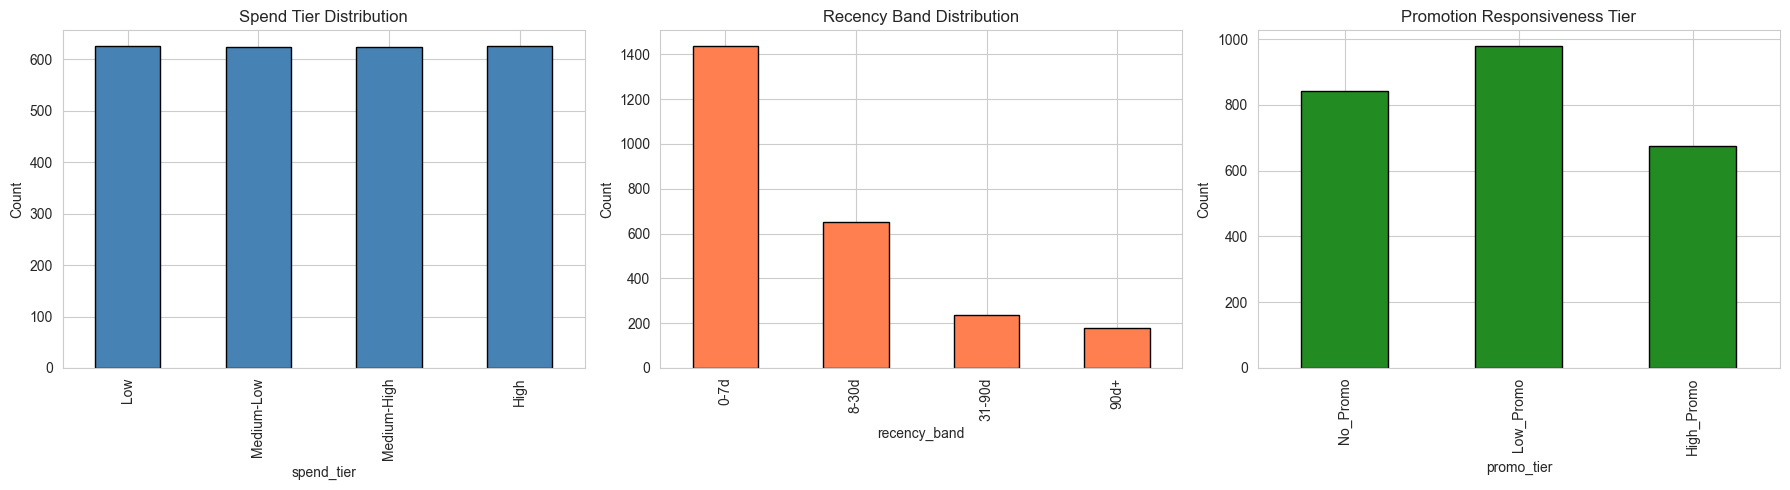

In [160]:
# ── 4f. Create stratification variables ──────────────────────────────────────
# Spend tier: quartile-based
hh_features['spend_tier'] = pd.qcut(hh_features['avg_weekly_spend'], q=4, 
                                     labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

# Recency band
hh_features['recency_band'] = pd.cut(hh_features['recency_days'], 
                                      bins=[-1, 7, 30, 90, float('inf')],
                                      labels=['0-7d', '8-30d', '31-90d', '90d+'])

# Promotion responsiveness tier
hh_features['promo_tier'] = pd.cut(hh_features['coupon_usage_rate'], 
                                   bins=[-1, 0, 0.01, 1],
                                   labels=['No_Promo', 'Low_Promo', 'High_Promo'],
                                   duplicates='drop')

# Display stratification summary
strat_summary = hh_features.groupby(['spend_tier', 'recency_band']).size().unstack(fill_value=0)
print("=== Stratification: Spend Tier x Recency Band ===")
print(strat_summary)
print(f"\nTotal households: {len(hh_features)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
hh_features['spend_tier'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Spend Tier Distribution')
axes[0].set_ylabel('Count')

hh_features['recency_band'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Recency Band Distribution')
axes[1].set_ylabel('Count')

hh_features['promo_tier'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='forestgreen', edgecolor='black')
axes[2].set_title('Promotion Responsiveness Tier')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 5. Post-Period Outcome Variables

We also compute post-period outcomes for each household. These will be used later to simulate what the experiment results might look like and to validate our power calculations.

In [162]:
# ── 5. Post-period household outcomes ────────────────────────────────────────
post_weeks = 102 - POST_PERIOD_START + 1  # 31 weeks

hh_post = txn_post.groupby('household_key').agg(
    post_total_spend  = ('SALES_VALUE', 'sum'),
    post_total_trips  = ('BASKET_ID', 'nunique'),
    post_total_items  = ('QUANTITY', 'sum')
).reset_index()

hh_post['post_avg_weekly_spend'] = hh_post['post_total_spend'] / post_weeks
hh_post['post_spend_per_trip'] = hh_post['post_total_spend'] / hh_post['post_total_trips']
hh_post['post_items_per_trip'] = hh_post['post_total_items'] / hh_post['post_total_trips']

# Merge with features — left join to keep all pre-period households
hh_full = hh_features.merge(hh_post, on='household_key', how='left')

# Households active in pre but not post → churned (spend = 0)
for col in ['post_total_spend', 'post_total_trips', 'post_total_items', 'post_avg_weekly_spend']:
    hh_full[col] = hh_full[col].fillna(0)

hh_full['post_active'] = (hh_full['post_total_spend'] > 0).astype(int)

print(f"Full household table: {hh_full.shape}")
print(f"  Active in both periods: {hh_full['post_active'].sum()}")
print(f"  Churned (no post spend): {(~hh_full['post_active'].astype(bool)).sum()}")
print(f"\n=== Pre vs Post Avg Weekly Spend ===")
print(f"  Pre-period mean:  ${hh_full['avg_weekly_spend'].mean():.2f}")
print(f"  Post-period mean: ${hh_full['post_avg_weekly_spend'].mean():.2f}")

Full household table: (2498, 50)
  Active in both periods: 2444
  Churned (no post spend): 54

=== Pre vs Post Avg Weekly Spend ===
  Pre-period mean:  $34.22
  Post-period mean: $35.78


## 6. Save Prepared Data

We export the household-level feature table for use in Notebook 2 (Experiment Design).

In [164]:
# ── 6. Save prepared household table ─────────────────────────────────────────
hh_full.to_csv(DATA_DIR + 'hh_features.csv', index=False)
print(f"Saved hh_features.csv with {len(hh_full)} households and {hh_full.shape[1]} columns.")
print(f"\nColumns: {list(hh_full.columns)}")

Saved hh_features.csv with 2498 households and 50 columns.

Columns: ['household_key', 'total_spend', 'total_items', 'total_trips', 'total_days_active', 'total_weeks_active', 'n_products', 'n_stores', 'n_departments', 'last_purchase_day', 'first_purchase_day', 'first_purchase_week', 'avg_basket_value', 'avg_weekly_spend', 'avg_trips_per_week', 'items_per_trip', 'spend_per_trip', 'recency_days', 'coupon_usage_rate', 'discounted_coupon_rate', 'loyalty_usage_rate', 'total_discount', 'n_coupon_items', 'n_coupon_discount_items', 'discount_per_trip', 'top_department', 'age_group', 'marital_status', 'income_level', 'homeowner', 'household_comp', 'household_size', 'kid_category', 'n_campaigns_received', 'n_campaigns_TypeA', 'n_campaigns_TypeB', 'n_campaigns_TypeC', 'n_coupons_redeemed', 'n_campaigns_redeemed', 'has_redeemed', 'spend_tier', 'recency_band', 'promo_tier', 'post_total_spend', 'post_total_trips', 'post_total_items', 'post_avg_weekly_spend', 'post_spend_per_trip', 'post_items_per_tr

## Summary

**Key findings from data exploration:**

1. **Scale:** ~2,500 households, ~2.6M transaction lines over 102 weeks
2. **Spend distribution:** Right-skewed — a power analysis on raw spend will require careful variance handling (winsorization or log-transform)
3. **Demographics:** Available for ~800 households (a subset); the experiment design will not require demographics for eligibility but will use them for subgroup analysis
4. **Campaign history:** The observed redemption rate of 17.4% provides a reasonable baseline for coupon response, although it may be slightly upward biased due to targeted campaign exposure.
5. **Stratification variables created:** Spend tier (quartiles), recency band, promotion responsiveness tier — these will be used for balanced randomization

**Next:** Notebook 2 uses these baselines to design the full A/B test (Steps 1–14 of the Experiment Design Plan).